In [199]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [200]:
df = pd.read_csv("final_district_feature_table.csv")
FEATURES = [
    # Crime
    'crime_all_rt',                          # 0
    'crime_viol_rt',                         # 1
    # Education
    'pct_prof_math',                         # 2
    'pct_prof_ela',                          # 3
    # Transport
    'mta_station_count',                     # 4
    'mta_route_count_log1p',                 # 5
    'mta_station_density_per_sq_km_log1p',   # 6
    # Parks
    'parks_total_acres_log1p',               # 7
    'parks_neighborhood_park_count',         # 8
    'parks_playground_count',                # 9
    'parks_acres_per_sq_km_log1p',           # 10
]

In [201]:
BOROUGH_MAP = {
    # Manhattan
    'Battery Park/Tribeca':              'Manhattan',
    'Central Harlem':                    'Manhattan',
    'Chelsea/Clinton':                   'Manhattan',
    'Clinton/Chelsea':                   'Manhattan',
    'East Harlem':                       'Manhattan',
    'Financial District':                'Manhattan',
    'Gramercy/Murray Hill':              'Manhattan',
    'Greenwich Village/Soho':            'Manhattan',
    'Inwood/Washington Heights':         'Manhattan',
    'Lower East Side/Chinatown':         'Manhattan',
    'Midtown':                           'Manhattan',
    'Morningside Heights/Hamilton':      'Manhattan',
    'Stuyvesant Town/Turtle Bay':        'Manhattan',
    'Upper East Side':                   'Manhattan',
    'Upper West Side':                   'Manhattan',
    'Washington Heights/Inwood':         'Manhattan',
    # Brooklyn
    'Bay Ridge/Dyker Heights':           'Brooklyn',
    'Bedford Stuyvesant':                'Brooklyn',
    'Bensonhurst':                       'Brooklyn',
    'Borough Park':                      'Brooklyn',
    'Brownsville':                       'Brooklyn',
    'Bushwick':                          'Brooklyn',
    'Canarsie/Flatlands':                'Brooklyn',
    'Coney Island':                      'Brooklyn',
    'Crown Heights/Prospect Heights':    'Brooklyn',
    'East Flatbush':                     'Brooklyn',
    'East New York':                     'Brooklyn',
    'Flatbush/Midwood':                  'Brooklyn',
    'Fort Greene/Brooklyn Heights':      'Brooklyn',
    'Greenpoint/Williamsburg':           'Brooklyn',
    'Park Slope/Carroll Gardens':        'Brooklyn',
    'Sheepshead Bay':                    'Brooklyn',
    'Sunset Park':                       'Brooklyn',
    'Williamsburg/Bushwick':             'Brooklyn',
    'East New York/Starrett City':       'Brooklyn',
    'South Crown Heights/Lefferts Gardens':   'Brooklyn',
    'Flatlands/Canarsie': 'Brooklyn',
    # Queens
    'Astoria':                           'Queens',
    'Bayside/Little Neck':               'Queens',
    'Elmhurst/Corona':                   'Queens',
    'Flushing/Whitestone':               'Queens',
    'Hillcrest/Fresh Meadows':           'Queens',
    'Jackson Heights':                   'Queens',
    'Jamaica/Hollis':                    'Queens',
    'Kew Gardens/Woodhaven':             'Queens',
    'Long Island City/Astoria':          'Queens',
    'Queens Village':                    'Queens',
    'Rego Park/Forest Hills':            'Queens',
    'Ridgewood/Maspeth':                 'Queens',
    'Rockaway/Broad Channel':            'Queens',
    'South Ozone Park/Howard Beach':     'Queens',
    'Woodside/Sunnyside':                'Queens',
    # Bronx
    'Belmont/East Tremont':              'Bronx',
    'Co-op City':                        'Bronx',
    'Fordham/University Heights':        'Bronx',
    'Highbridge/Concourse':              'Bronx',
    'Hunts Point/Longwood':              'Bronx',
    'Kingsbridge/Riverdale':             'Bronx',
    'Morris Park/Bronxdale':             'Bronx',
    'Morrisania/Crotona':                'Bronx',
    'Mott Haven/Melrose':                'Bronx',
    'Pelham/Throgs Neck':                'Bronx',
    'Wakefield/Williamsbridge':          'Bronx',
    'Kingsbridge Heights/Bedford':            'Bronx',
    'Riverdale/Fieldston':                    'Bronx',
    'Parkchester/Soundview':                  'Bronx',
    'Throgs Neck/Co-op City':                 'Bronx',
    'Williamsbridge/Baychester':              'Bronx',
    # Staten Island
    'South Beach/Willowbrook':           'Staten Island',
    'St. George/Stapleton':              'Staten Island',
    'Tottenville/Great Kills':           'Staten Island',
}

VALID_BOROUGHS = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']

df['borough'] = df['region_name'].map(BOROUGH_MAP)
unmapped = df[df['borough'].isna()]['region_name'].tolist()
if unmapped:
    print(f"⚠ Unmapped regions (add to BOROUGH_MAP): {unmapped}")

In [ ]:
# ── Cleaning & Normalization ───────────────────────────────────────────────────
meta_cols = ['region_id', 'region_display', 'region_name']
df_clean  = df.copy()

# Invert crime rates so higher = better (monotonic with other features)
df_clean['crime_all_rt']  = -df_clean['crime_all_rt']
df_clean['crime_viol_rt'] = -df_clean['crime_viol_rt']

# Outlier detection
from scipy import stats
z_scores = np.abs(stats.zscore(df_clean[FEATURES]))
print("\nOutliers detected (|z| > 3):")
for i, col in enumerate(FEATURES):
    hits = df_clean['region_name'][z_scores[:, i] > 3].tolist()
    if hits:
        vals = df_clean.loc[z_scores[:, i] > 3, col].values.round(2)
        print(f"  {col}: {hits} → {vals}")

# Winsorize at 1.7th/98.3rd percentile
from scipy.stats.mstats import winsorize
df_winsorized = df_clean.copy()
for col in FEATURES:
    df_winsorized[col] = winsorize(df_clean[col], limits=[0.017, 0.017])

print("\nEffect of winsorizing on outlier features:")
for col in ['crime_all_rt', 'crime_viol_rt', 'mta_station_count',
            'parks_neighborhood_park_count']:
    before = df_clean[col].max()
    after  = df_winsorized[col].max()
    if before != after:
        print(f"  {col}: {before:.2f} → {after:.2f}")

# Standardize (must be after winsorizing)
scaler   = StandardScaler()
X        = df_winsorized[FEATURES].values
X_scaled = scaler.fit_transform(X)

# Derived display feature
df_winsorized['school_avg'] = (
    df_winsorized['pct_prof_math'] + df_winsorized['pct_prof_ela']
) / 2


Outliers detected (|z| > 3):
  crime_all_rt: ['Midtown'] → [-81.4]
  crime_viol_rt: ['Midtown'] → [-17.1]
  mta_station_count: ['Midtown'] → [31]
  mta_station_density_per_sq_km_log1p: ['Midtown'] → [2.15]
  parks_neighborhood_park_count: ['St. George/Stapleton'] → [18.]
  parks_playground_count: ['Fordham/University Heights', 'Greenpoint/Williamsburg'] → [15. 18.]

Effect of winsorizing on outlier features:
  crime_all_rt: -4.20 → -5.40
  crime_viol_rt: -1.10 → -1.20
  mta_station_count: 31.00 → 24.00
  parks_neighborhood_park_count: 18.00 → 12.00


In [203]:
# ── User Inputs ────────────────────────────────────────────────────────────────
user_weights = {
    'Safety':  5,
    'Schools': 5,
    'Transit': 2,
    'Parks':   2,
}

user_rent_budget = 3800
user_bedrooms    = 1

user_boroughs = ['Manhattan']

if user_boroughs is not None:
    invalid = [b for b in user_boroughs if b not in VALID_BOROUGHS]
    if invalid:
        raise ValueError(f"Invalid borough(s): {invalid}. Choose from {VALID_BOROUGHS}")
    print(f"Borough filter active: {user_boroughs}")
else:
    print("Borough filter: all boroughs")

# Each vector selects which raw features belong to a category.
# Entries are averaged (normalized), so unequal category sizes are handled.
PRIORITY_VECTORS = {
    'Safety':  np.array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=float),
    'Schools': np.array([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0], dtype=float),
    'Transit': np.array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], dtype=float),
    'Parks':   np.array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], dtype=float),
}

for k in PRIORITY_VECTORS:
    PRIORITY_VECTORS[k] /= PRIORITY_VECTORS[k].sum()

Borough filter active: ['Manhattan']


In [ ]:
# ── Custom User-Relevance Projection (Option 2) ────────────────────────────────
from numpy.linalg import qr

CATEGORIES = ['Safety', 'Schools', 'Transit', 'Parks']

basis = np.array([PRIORITY_VECTORS[c] for c in CATEGORIES])  # (4, 11)

Q, _ = qr(basis.T)                       # Q shape: (11, 4)
Q    = Q[:, :len(CATEGORIES)].T          # (4, 11)

# QR column signs are arbitrary — ensure each axis points toward
# its category's positive direction (more transit = higher score, etc.)
for i in range(len(CATEGORIES)):
    if np.dot(Q[i], basis[i]) < 0:
        Q[i] *= -1

X_proj = X_scaled @ Q.T      # (n_districts, 4)

print("Projection axes (rows = orthogonalized category directions):")
for i, cat in enumerate(CATEGORIES):
    top_feats = pd.Series(Q[i], index=FEATURES).abs().sort_values(ascending=False).head(4)
    print(f"  Axis {i+1} ({cat}): {dict(top_feats.round(3))}")

print(f"\nX_proj shape: {X_proj.shape}")

# Sanity check — top/bottom districts per axis should make intuitive sense
for i, cat in enumerate(CATEGORIES):
    top = df_winsorized['region_name'].iloc[X_proj[:, i].argsort()[-3:][::-1]].tolist()
    bot = df_winsorized['region_name'].iloc[X_proj[:, i].argsort()[:3]].tolist()
    print(f"  {cat} — top: {top}  |  bottom: {bot}")


Projection axes (rows = orthogonalized category directions):
  Axis 1 (Safety): {'crime_viol_rt': np.float64(0.707), 'crime_all_rt': np.float64(0.707), 'pct_prof_math': np.float64(0.0), 'pct_prof_ela': np.float64(0.0)}
  Axis 2 (Schools): {'pct_prof_math': np.float64(0.707), 'pct_prof_ela': np.float64(0.707), 'crime_all_rt': np.float64(0.0), 'crime_viol_rt': np.float64(0.0)}
  Axis 3 (Transit): {'mta_station_count': np.float64(0.577), 'mta_route_count_log1p': np.float64(0.577), 'mta_station_density_per_sq_km_log1p': np.float64(0.577), 'crime_all_rt': np.float64(0.0)}
  Axis 4 (Parks): {'parks_total_acres_log1p': np.float64(0.5), 'parks_neighborhood_park_count': np.float64(0.5), 'parks_playground_count': np.float64(0.5), 'parks_acres_per_sq_km_log1p': np.float64(0.5)}

X_proj shape: (59, 4)
  Safety — top: ['Tottenville/Great Kills', 'Borough Park', 'Bay Ridge/Dyker Heights']  |  bottom: ['Midtown', 'Mott Haven/Melrose', 'Hunts Point/Longwood']
  Schools — top: ['Financial District', 'M

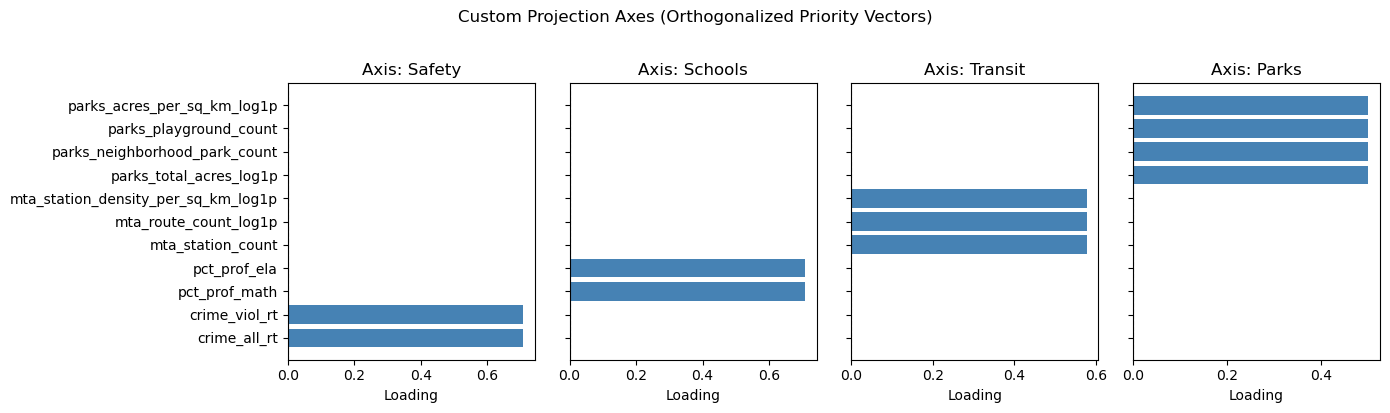

In [205]:
# ── Projection Inspection ──────────────────────────────────────────────────────
# Visualize how much each original feature loads onto each custom axis.
# This is the equivalent of PCA's loading plot.

fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(14, 4), sharey=True)

for i, (ax, cat) in enumerate(zip(axes, CATEGORIES)):
    loadings = pd.Series(Q[i], index=FEATURES)
    colors   = ['steelblue' if v >= 0 else 'tomato' for v in loadings]
    ax.barh(loadings.index, loadings.values, color=colors)
    ax.axvline(0, linestyle='--', color='gray', linewidth=0.8)
    ax.set_title(f'Axis: {cat}')
    ax.set_xlabel('Loading')

plt.suptitle('Custom Projection Axes (Orthogonalized Priority Vectors)', y=1.02)
plt.tight_layout()
plt.show()

In [206]:
# ── User Query Vector ──────────────────────────────────────────────────────────
# Normalized category weights — one per axis in the 4-d projected space
cat_weights  = np.array([user_weights[c] for c in CATEGORIES], dtype=float)
cat_weights /= cat_weights.sum()

print(f"Category weights: {dict(zip(CATEGORIES, cat_weights.round(3)))}")


Category weights: {'Safety': np.float64(0.357), 'Schools': np.float64(0.357), 'Transit': np.float64(0.143), 'Parks': np.float64(0.143)}


In [207]:
# ── Budget Fit (two-sided price preference) ────────────────────────────────────

BEDROOM_MAP = {
    0: ('gross_rent_0_1beds_usd', 'ah_studio_share'),
    1: ('gross_rent_0_1beds_usd', 'ah_1br_share'),
    2: ('gross_rent_2_3beds_usd', 'ah_2br_share'),
    3: ('gross_rent_2_3beds_usd', 'ah_3br_share'),
}

rent_col, share_col = BEDROOM_MAP[user_bedrooms]

def budget_fit(district_rent, budget,
               over_steepness=0.004, over_center_pct=0.05,
               under_steepness=0.001, under_center_pct=0.50):
    """
    Two-sided price-preference curve.

    Interprets the user's budget as a preferred price point rather than only a
    hard ceiling:
      - neighborhoods slightly under budget score well
      - neighborhoods far under budget are softened
      - neighborhoods above budget are penalized more sharply

    Centers scale with budget so behavior is stable across price levels.
      over_center_pct=0.10  → ~50% penalty when 10% over budget
      under_center_pct=0.50 → ~50% penalty when 50% under budget
    """
    if pd.isna(district_rent):
        return np.nan

    if district_rent > budget:
        center = budget * over_center_pct
        return 1 / (1 + np.exp(over_steepness * (district_rent - budget - center)))
    else:
        center = budget * under_center_pct
        return 1 / (1 + np.exp(under_steepness * (budget - district_rent - center)))

rent_series = df_winsorized[rent_col]
raw_share   = df_winsorized[share_col].fillna(0).clip(0, 1)

df_winsorized['budget_fit'] = rent_series.apply(lambda r: budget_fit(r, user_rent_budget))

# Bedroom mix acts as a soft availability modifier rather than a hard gate.
df_winsorized['unit_availability'] = np.sqrt(raw_share)

availability_weight = 0.25
df_winsorized['price_fit_factor'] = (
    df_winsorized['budget_fit'] *
    (1 - availability_weight + availability_weight * df_winsorized['unit_availability'])
)

print("Price-fit factor stats:")
print(df_winsorized['price_fit_factor'].describe().round(3))

print("\nSample — rent vs price fit:")
sample = df_winsorized[['region_name', rent_col, 'budget_fit', 'unit_availability', 'price_fit_factor']].copy()
print(sample.sort_values(rent_col).iloc[::8].to_string(index=False))


Price-fit factor stats:
count    59.000
mean      0.411
std       0.114
min       0.268
25%       0.329
50%       0.383
75%       0.455
max       0.723
Name: price_fit_factor, dtype: float64

Sample — rent vs price fit:
               region_name  gross_rent_0_1beds_usd  budget_fit  unit_availability  price_fit_factor
      Hunts Point/Longwood                    1060    0.301535           0.555960          0.268061
              Coney Island                    1250    0.342990           0.738750          0.320588
   South Beach/Willowbrook                    1410    0.379894           0.876652          0.368179
       Flushing/Whitestone                    1570    0.418241           0.677687          0.384539
   Bay Ridge/Dyker Heights                    1660    0.440286           0.000000          0.330215
         Ridgewood/Maspeth                    1710    0.452642           0.707107          0.419498
                  Bushwick                    2030    0.532454           0.75337

In [208]:
# ── Scoring ───────────────────────────────────────────────────────────────────
# Weighted dot product in the 4D category space:
# score = sum of (district strength on each category axis × user priority weight)
# This rewards strong performance on top-weighted dimensions directly.
preference_scores = (X_proj * cat_weights).sum(axis=1)
preference_scores_pos = np.clip(preference_scores, 0, None)

df_winsorized = df_winsorized.copy()
df_winsorized["preference_score"] = preference_scores_pos
df_winsorized["final_score"] = (
    preference_scores * df_winsorized["price_fit_factor"]
)
df_winsorized['borough'] = df['borough'].values

results = df_winsorized[['region_name', 'region_display', 'borough']].copy()
results["preference_score"] = df_winsorized["preference_score"].round(4)
results["price_fit_factor"] = df_winsorized["price_fit_factor"].round(3)
results["final_score"] = df_winsorized["final_score"].round(4)
results["crime_viol_rt"] = df_winsorized["crime_viol_rt"].round(2)
results["school_avg"] = df_winsorized["school_avg"].round(1)
results["mta_station_count"] = df_winsorized["mta_station_count"]


if user_boroughs is not None:
    results = results[results['borough'].isin(user_boroughs)]

top5 = results.sort_values('final_score', ascending=False).head(5).reset_index(drop=True)
top5.index += 1

print("Top 5 Neighborhoods\n")
print(
    top5[
        [
            "region_name",
            "preference_score",
            "price_fit_factor",
            "final_score",
            "crime_viol_rt",
            "school_avg",
            "mta_station_count",
        ]
    ].to_string()
)

Top 5 Neighborhoods

                  region_name  preference_score  price_fit_factor  final_score  crime_viol_rt  school_avg  mta_station_count
1          Financial District            1.4534             0.703       1.0214           -4.5        87.4                 24
2  Stuyvesant Town/Turtle Bay            1.3460             0.715       0.9626           -2.3        84.5                  3
3             Upper East Side            1.5091             0.584       0.8819           -1.8        86.4                 10
4             Upper West Side            0.9122             0.554       0.5058           -2.3        71.6                  7
5      Greenwich Village/Soho            0.4847             0.723       0.3503           -6.2        82.2                 18


In [209]:
# ── Explanation Cell ───────────────────────────────────────────────────────────
# Rank districts using the same 4D category projection used by the recommender.
top_pref = results.sort_values('preference_score', ascending=False).head(3)
if top_pref['price_fit_factor'].mean() < 0.3:
    print("⚠ Your top preference matches are mostly over budget. "
          "Consider raising budget or adjusting weights.")


cat_score_df = pd.DataFrame(X_proj, columns=CATEGORIES, index=df_winsorized['region_name'])
cat_rank_df = cat_score_df.rank(ascending=False, method='min').astype(int)

top_results = results.sort_values('final_score', ascending=False).head(10)
ordered_cats = sorted(CATEGORIES, key=lambda c: user_weights[c], reverse=True)
n = len(df_winsorized)

# Header line
borough_label = ', '.join(user_boroughs) if user_boroughs else 'All boroughs'
print(f"User: ${user_rent_budget}/mo budget · {user_bedrooms}BR · {borough_label}")
print(f"Weights: { {c: user_weights[c] for c in ordered_cats} }\n")

for rank, (_, row) in enumerate(top_results.iterrows(), 1):
    name = row['region_name']
    district = df_winsorized.loc[df_winsorized['region_name'] == name].iloc[0]
    ranks = cat_rank_df.loc[name]
    if isinstance(ranks, pd.DataFrame):
        ranks = ranks.iloc[0]

    rent = district[rent_col]
    rent_note = f"${rent:,.0f}/mo" if pd.notna(rent) else "rent unknown"

    if pd.notna(rent):
        if rent > user_rent_budget:
            budget_note = "over budget"
        elif rent >= 0.8 * user_rent_budget:
            budget_note = "near target budget"
        else:
            budget_note = "well below target budget"
    else:
        budget_note = "budget unknown"

    best_cats = sorted(ordered_cats, key=lambda c: ranks[c])[:2]
    strengths_text = f"Strongest on {best_cats[0].lower()} and {best_cats[1].lower()}."

    print(f"{rank:>2}. {name} ({BOROUGH_MAP[name]})")
    print(
        f"    Score: {row['final_score']:.3f}  |  Preference: {row['preference_score']:.3f}  "
        f"|  Price fit: {row['price_fit_factor']:.3f}  |  Rent: {rent_note} ({budget_note})"
    )
    print(f"    {strengths_text}")
    print("    " + "  |  ".join(f"{c}: #{ranks[c]} of {n}" for c in ordered_cats))
    print()


User: $3800/mo budget · 1BR · Manhattan
Weights: {'Safety': 5, 'Schools': 5, 'Transit': 2, 'Parks': 2}

 1. Financial District (Manhattan)
    Score: 1.021  |  Preference: 1.453  |  Price fit: 0.703  |  Rent: $3,350/mo (near target budget)
    Strongest on schools and transit.
    Safety: #38 of 59  |  Schools: #1 of 59  |  Transit: #2 of 59  |  Parks: #50 of 59

 2. Stuyvesant Town/Turtle Bay (Manhattan)
    Score: 0.963  |  Preference: 1.346  |  Price fit: 0.715  |  Rent: $2,930/mo (well below target budget)
    Strongest on schools and safety.
    Safety: #10 of 59  |  Schools: #4 of 59  |  Transit: #38 of 59  |  Parks: #21 of 59

 3. Upper East Side (Manhattan)
    Score: 0.882  |  Preference: 1.509  |  Price fit: 0.584  |  Rent: $2,550/mo (well below target budget)
    Strongest on schools and transit.
    Safety: #11 of 59  |  Schools: #3 of 59  |  Transit: #9 of 59  |  Parks: #41 of 59

 4. Upper West Side (Manhattan)
    Score: 0.506  |  Preference: 0.912  |  Price fit: 0.554  